<a href="https://colab.research.google.com/github/kathy1124/colab/blob/main/PPE_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

導入作業系統

In [1]:
import os

返回所有檔案路徑

In [ ]:
import glob

顯示任何輸出或輸入名稱圖像

In [ ]:
from IPython.display import Image, display

清除筆記本中的輸出的

In [ ]:
from IPython.display import clear_output
clear_output()

# 檢查是否可以存取 GPU

In [ ]:
!nvidia-smi

Sat Jan 25 07:17:44 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   42C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

定義基本運行目錄

In [ ]:
HOME = os.getcwd()

In [ ]:
print(HOME)

/content


# Installing Ultralytics

In [ ]:
!pip install ultralytics==8.0.0

  Using cached ultralytics-8.0.0-py3-none-any.whl.metadata (23 kB)
  Using cached hydra_core-1.3.2-py3-none-any.whl.metadata (5.5 kB)
  Using cached thop-0.1.1.post2209072238-py3-none-any.whl.metadata (2.7 kB)
Using cached ultralytics-8.0.0-py3-none-any.whl (219 kB)
Using cached hydra_core-1.3.2-py3-none-any.whl (154 kB)
Using cached thop-0.1.1.post2209072238-py3-none-any.whl (15 kB)


In [ ]:
!pip install ultralytics --upgrade

檢查我們的 YOLO 模型是否安裝並且正常工作

In [ ]:
import ultralytics

In [ ]:
ultralytics.checks()

Ultralytics YOLOv8.0.0 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 31.1/112.6 GB disk)


# **Importing the PPE Detection Dataset from Roboflow**

建立資料夾

In [ ]:
!mkdir {HOME}/datasets

mkdir: cannot create directory ‘/content/datasets’: File exists


In [ ]:
!pwd

/content


下載roboflow資料集

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="3V0dDFy4Srmx0xfN0b0R")
project = rf.workspace("trash-pem40").project("eep_detection-u9bbd-a6rqu")
version = project.version(1)
dataset = version.download("yolov5")

In [ ]:
%cd {HOME}

/content


In [ ]:
%cd {dataset.location}

/content/EEP_Detection-1


# 訓練模型

In [ ]:
%cd {HOME}
!yolo task=detect mode=train model=yolov8m.pt data=/content/EEP_Detection/data.yaml epochs=90 imgsz=640

串流輸出內容已截斷至最後 5000 行。
  with torch.cuda.amp.autocast(self.amp):
      74/90      9.71G     0.8533     0.5188      1.131         87        640:  44% 62/142 [00:36<00:43,  1.83it/s]/usr/local/lib/python3.11/dist-packages/ultralytics/yolo/engine/trainer.py:290: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.amp):
      74/90      9.71G      0.853     0.5193      1.131         86        640:  44% 63/142 [00:36<00:43,  1.82it/s]/usr/local/lib/python3.11/dist-packages/ultralytics/yolo/engine/trainer.py:290: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.amp):
      74/90      9.71G     0.8529      0.519      1.131         82        640:  45% 64/142 [00:37<00:44,  1.77it/s]/usr/local/lib/python3.11/dist-packages/ultralytics/yolo/engine/trainer.py:290: FutureWarning: `torch.

In [ ]:
!ls /content/runs/detect/train/

args.yaml					     F1_curve.png  predictions.json  results.png
confusion_matrix.png				     P_curve.png   R_curve.png	     weights
events.out.tfevents.1737790103.c36eba60ba8a.11049.0  PR_curve.png  results.csv


# 混淆矩陣
##     顯示我們的模型如何處理不同類別的圖表

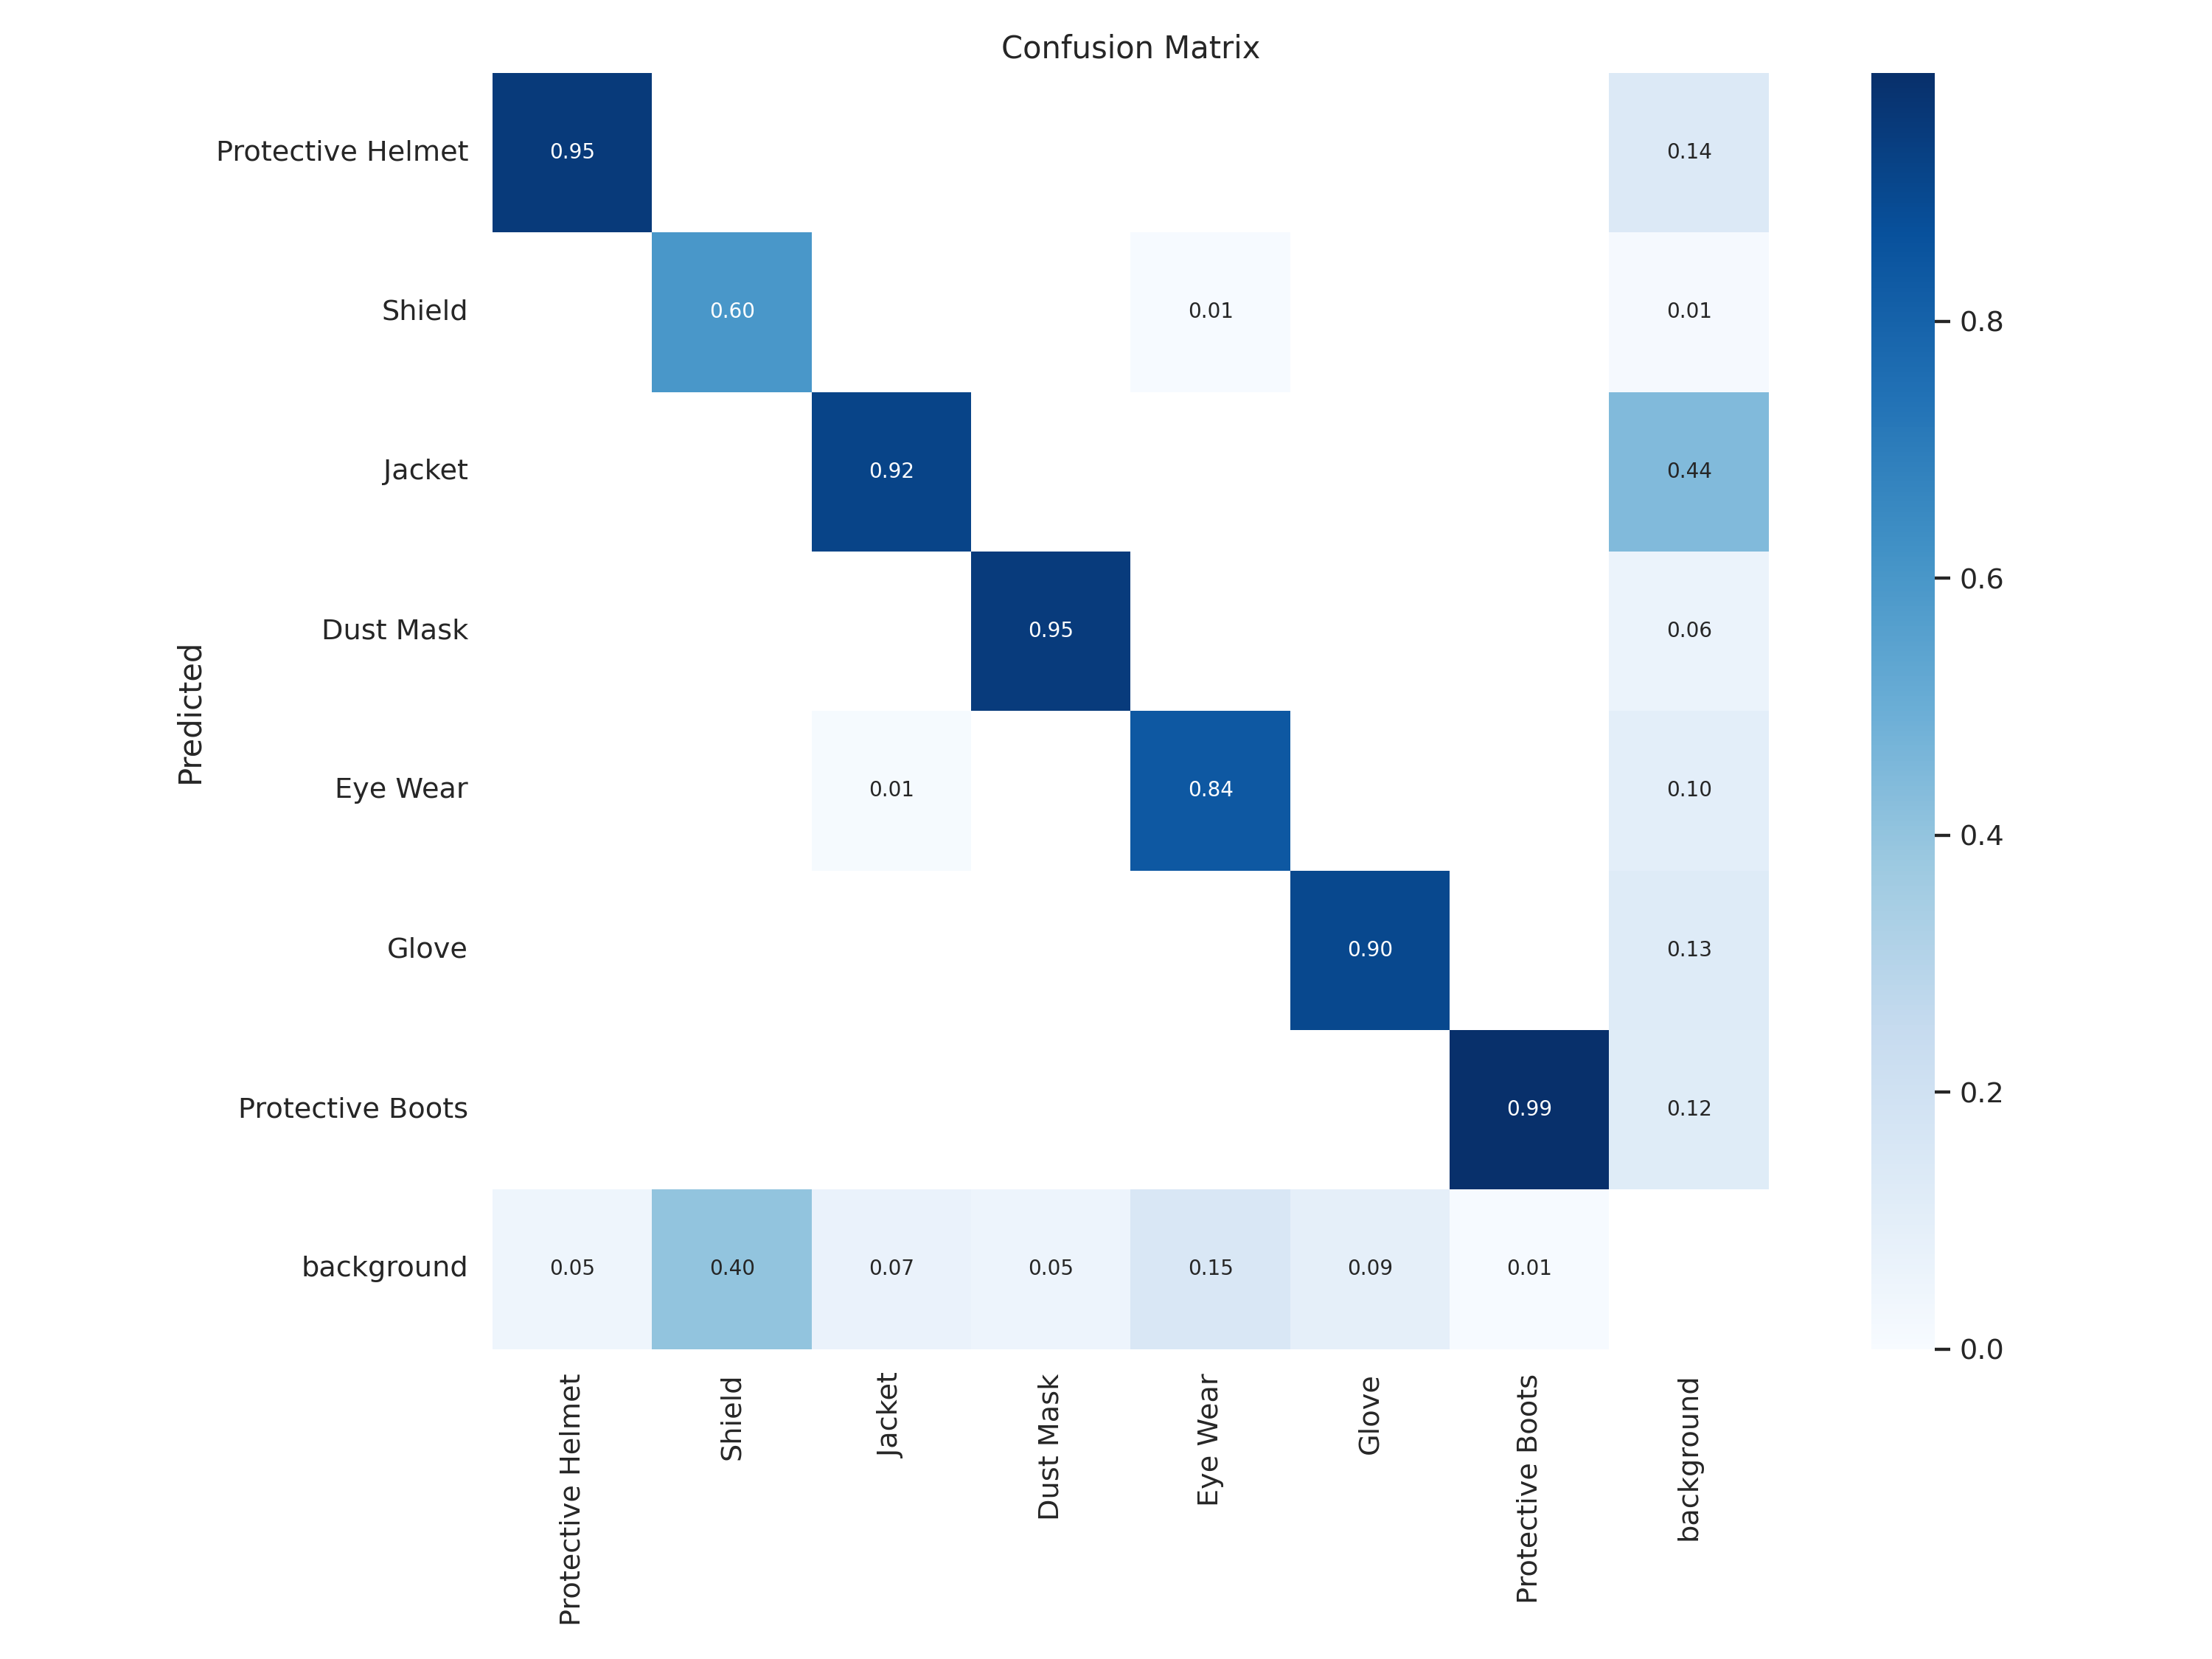

In [ ]:
Image(filename=f'/content/runs/detect/train/confusion_matrix.png', width=900)

# 訓練和驗證損失的圖表

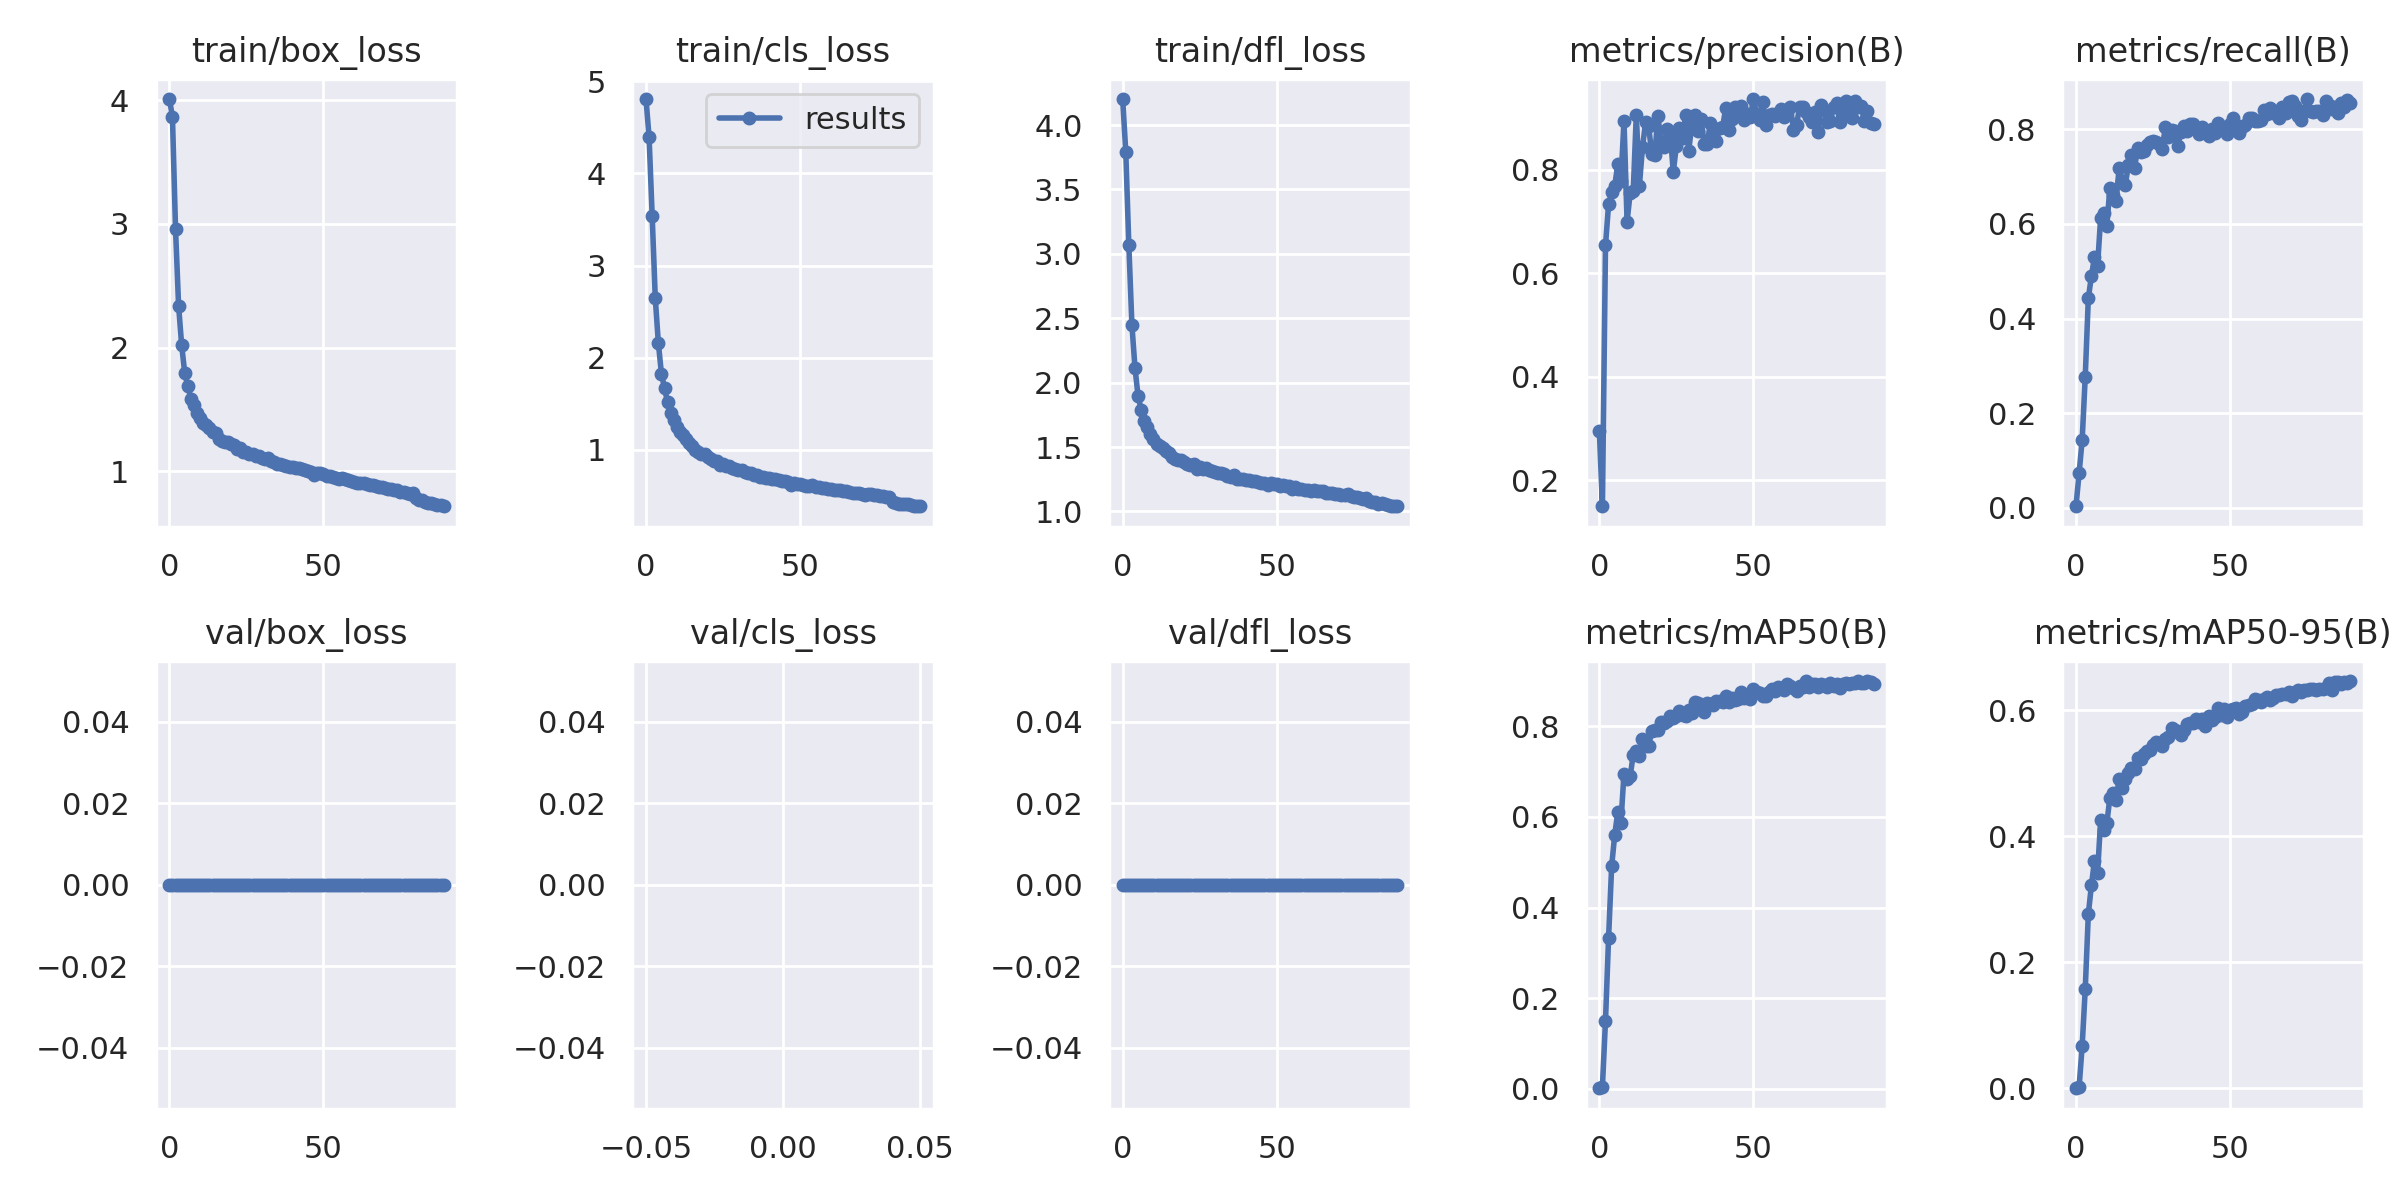

In [ ]:
Image(filename=f'/content/runs/detect/train/results.png', width=600)

# 驗證模型

In [ ]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.5/913.5 kB 23.1 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.0.0
    Uninstalling ultralytics-8.0.0:
      Successfully uninstalled ultralytics-8.0.0


In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/EEP_Detection/data.yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.67 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,843,813 parameters, 0 gradients, 78.7 GFLOPs
val: Scanning /content/EEP_Detection/valid/labels... 647 images, 0 backgrounds, 0 corrupt: 100% 647/647 [00:00<00:00, 1907.49it/s]
val: New cache created: /content/EEP_Detection/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 41/41 [00:17<00:00,  2.40it/s]
                   all        647       3074      0.889      0.855      0.893      0.647
     Protective Helmet        408        765      0.965      0.946      0.979      0.775
                Shield 

# 自訂模型

In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.25 conf=0.25 source=/content/EEP_Detection/test/images

Ultralytics 8.3.67 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,843,813 parameters, 0 gradients, 78.7 GFLOPs

image 1/324 /content/EEP_Detection/test/images/000446_jpg.rf.ddc775dc20f28ad213847c1a54a8b56a.jpg: 640x640 2 Protective Helmets, 37.0ms
image 2/324 /content/EEP_Detection/test/images/20220721_161946_jpg.rf.e8cdd130e95905d29c7214607ed42f89.jpg: 640x640 (no detections), 37.0ms
image 3/324 /content/EEP_Detection/test/images/20220721_162015_jpg.rf.7a2f978b22d0be07ecf584cf09462563.jpg: 640x640 1 Dust Mask, 37.0ms
image 4/324 /content/EEP_Detection/test/images/20220721_162036_jpg.rf.6c3eafc4e601b0763bcf11dcb22d9427.jpg: 640x640 1 Dust Mask, 35.7ms
image 5/324 /content/EEP_Detection/test/images/20220721_162308_jpg.rf.5a79eb3fbe1869af9ce0916c296a489e.jpg: 640x640 1 Jacket, 1 Dust Mask, 1 Eye Wear, 2 Gloves, 29.9ms
image 6/324 /content/EEP_Detection/test/images/20220721_162435_jpg.rf.bfcf4e7bd6ada83e0cb55e4321b667ce.jpg: 640x640 1 

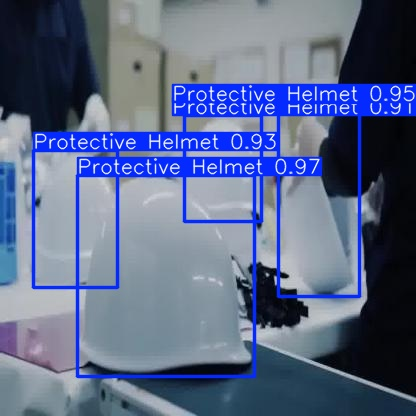

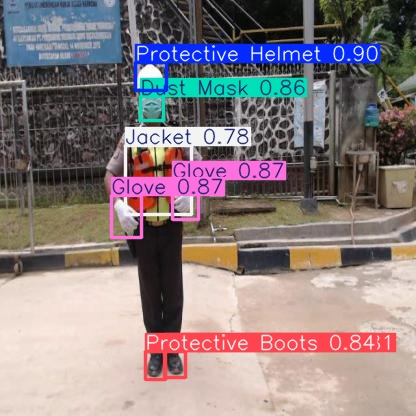

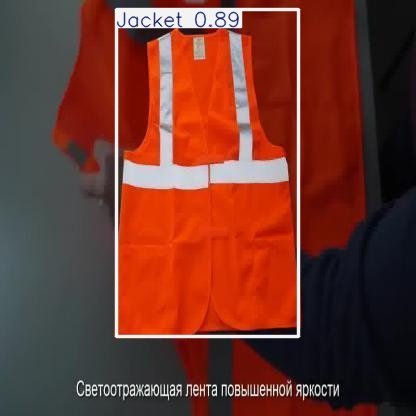

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:3]:
      display(Image(filename=image_path, width=600))
      print("\n")

#Testing on a Demo Video

In [ ]:
!gdown "https://drive.google.com/uc?id=1crFwrpMF1OlaJ0ZCZjBNRo9llLEVR8VQ&confirm=t"

Downloading...
From: https://drive.google.com/uc?id=1crFwrpMF1OlaJ0ZCZjBNRo9llLEVR8VQ&confirm=t
To: /content/demo.mp4
100% 42.9M/42.9M [00:00<00:00, 74.5MB/s]


In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.25 source='/content/demo.mp4'

Ultralytics 8.3.67 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,843,813 parameters, 0 gradients, 78.7 GFLOPs

video 1/1 (frame 1/439) /content/demo.mp4: 384x640 2 Protective Helmets, 2 Jackets, 97.5ms
video 1/1 (frame 2/439) /content/demo.mp4: 384x640 2 Protective Helmets, 2 Jackets, 25.2ms
video 1/1 (frame 3/439) /content/demo.mp4: 384x640 2 Protective Helmets, 2 Jackets, 25.2ms
video 1/1 (frame 4/439) /content/demo.mp4: 384x640 2 Protective Helmets, 2 Jackets, 25.3ms
video 1/1 (frame 5/439) /content/demo.mp4: 384x640 2 Protective Helmets, 2 Jackets, 25.2ms
video 1/1 (frame 6/439) /content/demo.mp4: 384x640 2 Protective Helmets, 2 Jackets, 25.2ms
video 1/1 (frame 7/439) /content/demo.mp4: 384x640 2 Protective Helmets, 2 Jackets, 25.2ms
video 1/1 (frame 8/439) /content/demo.mp4: 384x640 2 Protective Helmets, 2 Jackets, 25.2ms
video 1/1 (frame 9/439) /content/demo.mp4: 384x640 2 Protective Helmets, 2 Jackets, 25.2ms
video 1/1 (fram